# FPGA 部署權重量化:PTQ bit-width 掃描

對已訓練好的 checkpoint(`scale_10k_20260919_050446`,
`val_accuracy=0.9275`)做權重分布分析,再用 `salt_core/quant/ptq.py` 的
`quantize_params` 掃 bit-width,量測 PTQ(post-training,不重訓)造成的準確率掉點。

方法決策見 [`../../docs/規格書.md`](../../docs/規格書.md)「FPGA 部署:權重量化」,
完整推導見 [`../../docs/math/權重量化推導.md`](../../docs/math/權重量化推導.md),
待辦範圍見 [`../../docs/TODO.md`](../../docs/TODO.md)。

In [23]:
%matplotlib inline
import os

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import matplotlib.pyplot as plt
import numpy as np

from data.src.nmnist import NMNISTDataset
from example.models.conv_net import build_decoder, build_growth_policies
from example.paths import DATASET_ROOT, EXPERIMENTS_DIR
from example.utils import load_run_params, load_run_record, make_evaluate
from salt_core.quant.ptq import quantization_error, quantize_params
from viz.style import apply_style

apply_style()

## 參數

改這裡,不改函式庫。

In [24]:
RUN_NAME = "scale_10k_20260919_050446"
EXP_DIR = EXPERIMENTS_DIR / RUN_NAME
BITS_SWEEP = [8, 6, 5, 4, 3, 2]
PERCENTILE_SWEEP = [100.0, 99.9, 99.0, 95.0, 90.0, 85.0, 80.0, 70.0, 60.0, 50.0]
FIXED_BIT_FOR_COMPARISON = 4  # per-channel vs per-tensor、clip percentile 兩個掃描共用

## 載入 checkpoint、val split、評估函式

跟 `example/eval_test.py` 的 `evaluate_run` 同一套載入邏輯(`load_run_params` 讀權重跟
它自帶的網路、`make_evaluate`),val split 用 `run.yaml` 記的
`seed_val`/`val_size`,對到訓練當時實際看的 val set。

In [25]:
run_record = load_run_record(str(EXP_DIR))
model_cfg = run_record["config"]["model"]
data_cfg = run_record["config"]["data"]

network, params = load_run_params(str(EXP_DIR), "best")
layers = network.layers
decoder = build_decoder(model_cfg, layers)
decoder.validate(layers[-1])

dataset = NMNISTDataset(DATASET_ROOT, max_events=int(data_cfg["max_events"]))
val_split = dataset.build_split(seed=int(data_cfg["seed_val"]),
                                n_samples=int(data_cfg["val_size"]), which="val")

eval_batch_size = int(data_cfg.get("batch_size") or run_record["config"]["train"]["batch_size"])
evaluate = make_evaluate(network, decoder, eval_batch_size, build_growth_policies(model_cfg, layers))

In [26]:
baseline_accuracy, baseline_loss, _, _ = evaluate(params, val_split)
print(f"baseline (未量化): val_accuracy={baseline_accuracy:.4f}  val_loss={baseline_loss:.4f}")

baseline (未量化): val_accuracy=0.9275  val_loss=0.3913


## 權重分布:histogram + per-channel outlier

先看數值本身長怎樣,再決定量化 scheme 合不合理——per-channel 的前提是「不同
channel 的量級差很多」,這裡直接畫出來檢查,不是憑空假設。

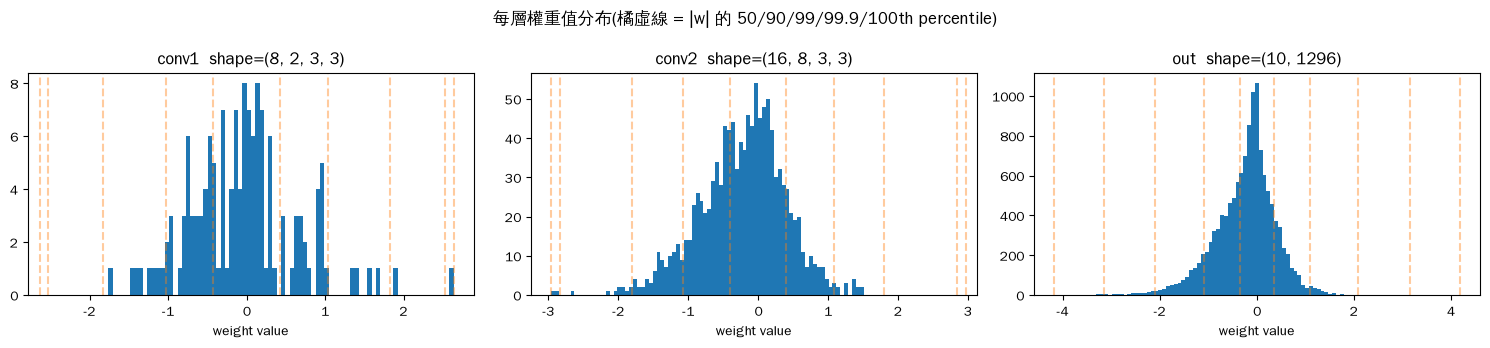

In [27]:
fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 3.5))
for ax, layer, w in zip(axes, layers, params):
    flat = np.asarray(w).ravel()
    ax.hist(flat, bins=80)
    for pct in (50, 90, 99, 99.9, 100):
        v = np.percentile(np.abs(flat), pct)
        ax.axvline(v, color="C1", alpha=0.4, linestyle="--")
        ax.axvline(-v, color="C1", alpha=0.4, linestyle="--")
    ax.set_title(f"{layer.name}  shape={w.shape}")
    ax.set_xlabel("weight value")
fig.suptitle("每層權重值分布(橘虛線 = |w| 的 50/90/99/99.9/100th percentile)")
fig.tight_layout()

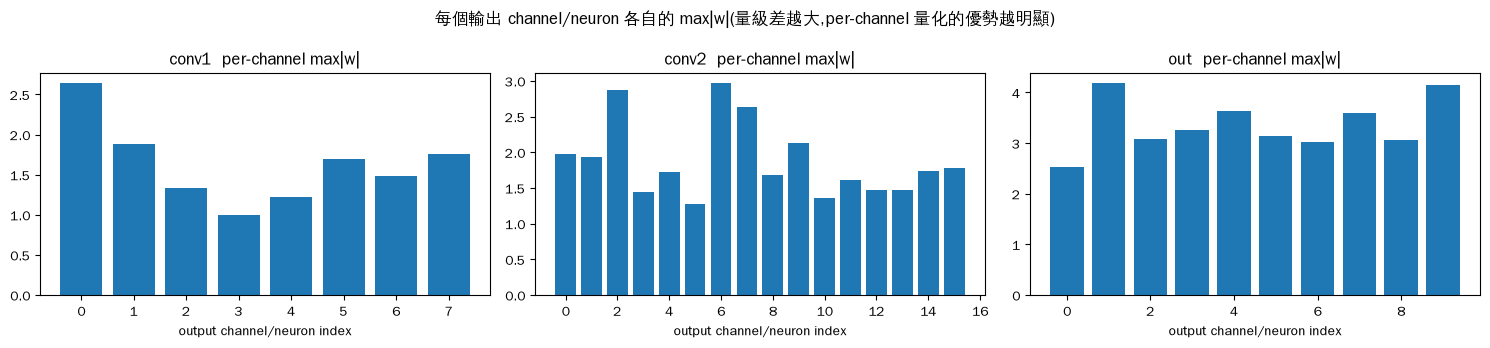

In [28]:
fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 3.5))
for ax, layer, w in zip(axes, layers, params):
    w_np = np.asarray(w)
    per_channel_max = np.max(np.abs(w_np.reshape(w_np.shape[0], -1)), axis=1)
    ax.bar(np.arange(per_channel_max.shape[0]), per_channel_max)
    ax.set_title(f"{layer.name}  per-channel max|w|")
    ax.set_xlabel("output channel/neuron index")
fig.suptitle("每個輸出 channel/neuron 各自的 max|w|(量級差越大,per-channel 量化的優勢越明顯)")
fig.tight_layout()

## bit-width 掃描(per-channel,clip_percentile=100 = max-abs)

目標硬體位寬候選最大 8 bits。掃到準確率明顯掉下去為止,找 PTQ(不重訓)能撐到
多低的 bit width;掉太多才需要考慮 QAT。

In [29]:
bit_sweep_results = []
for bits in BITS_SWEEP:
    q = quantize_params(params, bits=bits, per_channel=True)
    acc, loss, _, _ = evaluate(q, val_split)
    errs = [quantization_error(w, w_hat) for w, w_hat in zip(params, q)]
    mean_sqnr_db = float(np.mean([e["sqnr_db"] for e in errs]))
    bit_sweep_results.append(dict(bits=bits, accuracy=acc, loss=loss, mean_sqnr_db=mean_sqnr_db))
    print(f"bits={bits}: val_accuracy={acc:.4f}  val_loss={loss:.4f}  mean_sqnr_db={mean_sqnr_db:.2f}")

bits=8: val_accuracy=0.9265  val_loss=0.3952  mean_sqnr_db=42.47
bits=6: val_accuracy=0.9230  val_loss=0.4154  mean_sqnr_db=30.09
bits=5: val_accuracy=0.9205  val_loss=0.4459  mean_sqnr_db=23.91
bits=4: val_accuracy=0.8985  val_loss=0.6465  mean_sqnr_db=17.26
bits=3: val_accuracy=0.7310  val_loss=1.7635  mean_sqnr_db=10.34
bits=2: val_accuracy=0.1640  val_loss=4.1644  mean_sqnr_db=2.70


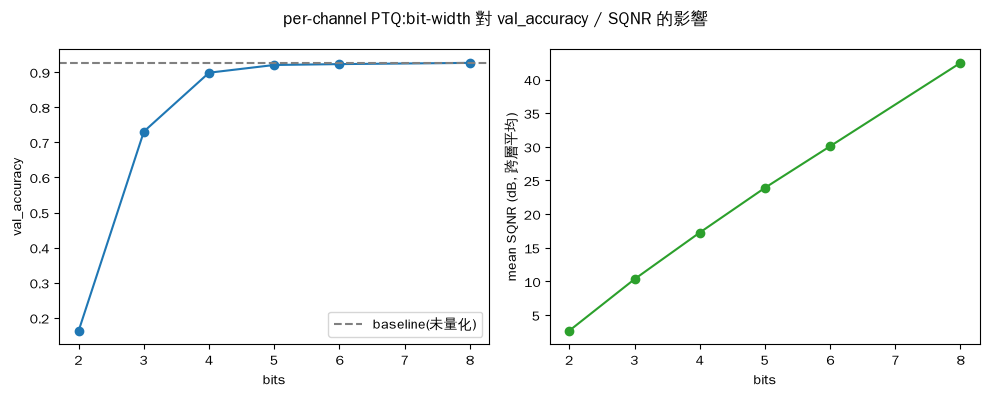

In [30]:
fig, (ax_acc, ax_sqnr) = plt.subplots(1, 2, figsize=(10, 4))
bits_axis = [r["bits"] for r in bit_sweep_results]
ax_acc.plot(bits_axis, [r["accuracy"] for r in bit_sweep_results], marker="o")
ax_acc.axhline(baseline_accuracy, color="gray", linestyle="--", label="baseline(未量化)")
ax_acc.set_xlabel("bits")
ax_acc.set_ylabel("val_accuracy")
ax_acc.legend()

ax_sqnr.plot(bits_axis, [r["mean_sqnr_db"] for r in bit_sweep_results], marker="o", color="C2")
ax_sqnr.set_xlabel("bits")
ax_sqnr.set_ylabel("mean SQNR (dB, 跨層平均)")
fig.suptitle("per-channel PTQ:bit-width 對 val_accuracy / SQNR 的影響")
fig.tight_layout()

## per-channel vs per-tensor 比較

固定 `FIXED_BIT_FOR_COMPARISON`,對照兩種量化軸的準確率差距——決定用
per-channel 是不是真的有幫助,不是憑理論假設。

In [31]:
for per_channel in (True, False):
    q = quantize_params(params, bits=FIXED_BIT_FOR_COMPARISON, per_channel=per_channel)
    acc, loss, _, _ = evaluate(q, val_split)
    label = "per-channel" if per_channel else "per-tensor"
    print(f"{label} @ bits={FIXED_BIT_FOR_COMPARISON}: val_accuracy={acc:.4f}  val_loss={loss:.4f}")

per-channel @ bits=4: val_accuracy=0.8985  val_loss=0.6465
per-tensor @ bits=4: val_accuracy=0.8830  val_loss=0.6391


## clip percentile 掃描

固定 `FIXED_BIT_FOR_COMPARISON`(bit width 較窄、outlier 影響比較明顯的地方),
掃 clip threshold 從 max-abs(100th percentile)往下收,看犧牲一點 outlier 的
精度換取一般值的量化解析度,划不划算。

In [32]:
percentile_sweep_results = []
for pct in PERCENTILE_SWEEP:
    q = quantize_params(params, bits=FIXED_BIT_FOR_COMPARISON,
                        per_channel=True, clip_percentile=pct)
    acc, loss, _, _ = evaluate(q, val_split)
    percentile_sweep_results.append(dict(percentile=pct, accuracy=acc, loss=loss))
    print(f"clip_percentile={pct}: val_accuracy={acc:.4f}  val_loss={loss:.4f}")

clip_percentile=100.0: val_accuracy=0.8985  val_loss=0.6465
clip_percentile=99.9: val_accuracy=0.8995  val_loss=0.5877
clip_percentile=99.0: val_accuracy=0.9080  val_loss=0.5365
clip_percentile=95.0: val_accuracy=0.9020  val_loss=0.4370
clip_percentile=90.0: val_accuracy=0.9185  val_loss=0.4181
clip_percentile=85.0: val_accuracy=0.8960  val_loss=0.4222
clip_percentile=80.0: val_accuracy=0.8870  val_loss=0.4772
clip_percentile=70.0: val_accuracy=0.8055  val_loss=0.7095
clip_percentile=60.0: val_accuracy=0.7690  val_loss=0.7385
clip_percentile=50.0: val_accuracy=0.6695  val_loss=1.0129


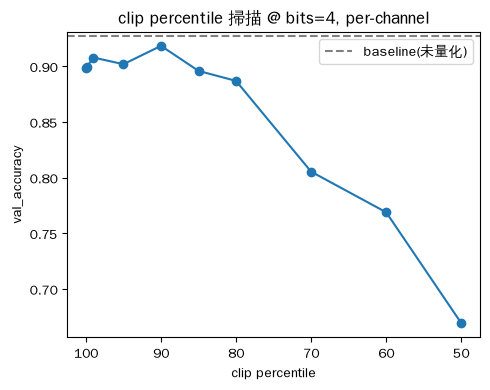

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([r["percentile"] for r in percentile_sweep_results],
       [r["accuracy"] for r in percentile_sweep_results], marker="o")
ax.axhline(baseline_accuracy, color="gray", linestyle="--", label="baseline(未量化)")
ax.set_xlabel("clip percentile")
ax.set_ylabel("val_accuracy")
ax.invert_xaxis()
ax.legend()
ax.set_title(f"clip percentile 掃描 @ bits={FIXED_BIT_FOR_COMPARISON}, per-channel")
fig.tight_layout()